In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib as plt
from sklearn.model_selection import GroupShuffleSplit
from  sklearn.ensemble import AdaBoostClassifier
import lightgbm as lgb
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score,precision_recall_curve,f1_score,precision_score, recall_score
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
import matplotlib.pyplot as plt
from torch_geometric.nn import GCNConv, knn_graph ,GATConv
from sklearn.preprocessing import StandardScaler
import joblib

c:\Users\kadir\OneDrive\Masaüstü\teknofest_saglıkt_YZ\pull_the_dataset\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df=pd.read_csv(r"C:\Users\kadir\OneDrive\Masaüstü\teknofest_saglıkt_YZ\pull_the_dataset\mdoel_test\data2_model_test\Dataset_V6_Master_Balanced_Filtered.csv")

In [3]:
print(df.head())
print(df.shape)

  CHROM        POS REF ALT  LABEL  aapos  codonpos  codon_degeneracy  \
0    10     997241   A   G      0  165.0       2.0               0.0   
1     1    1020246   C   G      0   25.0       2.0               0.0   
2    21   43066243   C   T      1  151.0       1.0               0.0   
3    19   13299094   G   A      1  847.0       1.0               0.0   
4     5  157240081   A   T      1  291.0       1.0               0.0   

                                     Interpro_domain  ESM1b_score  DANN_score  \
0                    NOG1, N-terminal helical domain    -8.948376    0.998207   
1                                                NaN    -3.680420    0.907942   
2  Tryptophan synthase beta chain-like, PALP doma...   -11.346376    0.998915   
3                                                  .    -9.741002    0.996737   
4  SH2 domain|SH2 domain|SH2 domain|Src homology ...   -15.158094    0.996018   

   GERP++_RS  phyloP100way  phastCons100way  bStatistic     gnomAD_AF  \
0      

In [4]:
print(df.columns)

Index(['CHROM', 'POS', 'REF', 'ALT', 'LABEL', 'aapos', 'codonpos',
       'codon_degeneracy', 'Interpro_domain', 'ESM1b_score', 'DANN_score',
       'GERP++_RS', 'phyloP100way', 'phastCons100way', 'bStatistic',
       'gnomAD_AF', 'POPMAX_AF'],
      dtype='str')


In [5]:
df=df.drop(columns=["CHROM", "REF", "ALT", "Interpro_domain","POS"] )

In [6]:
print(df.columns)

Index(['LABEL', 'aapos', 'codonpos', 'codon_degeneracy', 'ESM1b_score',
       'DANN_score', 'GERP++_RS', 'phyloP100way', 'phastCons100way',
       'bStatistic', 'gnomAD_AF', 'POPMAX_AF'],
      dtype='str')


In [7]:
print(df.head())

   LABEL  aapos  codonpos  codon_degeneracy  ESM1b_score  DANN_score  \
0      0  165.0       2.0               0.0    -8.948376    0.998207   
1      0   25.0       2.0               0.0    -3.680420    0.907942   
2      1  151.0       1.0               0.0   -11.346376    0.998915   
3      1  847.0       1.0               0.0    -9.741002    0.996737   
4      1  291.0       1.0               0.0   -15.158094    0.996018   

   GERP++_RS  phyloP100way  phastCons100way  bStatistic     gnomAD_AF  \
0       5.68         8.998             1.00       688.0  6.218310e-07   
1       1.70         0.522             0.16       934.0  6.874330e-07   
2       5.09         6.845             1.00       988.0  1.778090e-05   
3       2.20         2.672             1.00       929.0  2.131093e-03   
4       5.73         8.768             1.00       437.0 -3.443623e-04   

   POPMAX_AF  
0   0.000033  
1   0.000024  
2   0.000146  
3   0.005697  
4  -0.000660  


In [8]:
print(df.shape)

(204026, 12)


In [9]:
X = df.drop('LABEL', axis=1)
y = df['LABEL']

In [26]:


# 1. Aşama: Verinin %20'sini Final Testi için ayırıyoruz.
# Kalan %80'i (Temp) daha sonra Train ve Valid olarak böleceğiz.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y # Sınıf oranlarını (Zararlı/Zararsız) tüm setlerde eşit tutar
)

# 2. Aşama: Kalan %80'lik kısmı kendi içinde bölüyoruz.
# %80'in çeyreği (%25) tam olarak %20'ye denk geldiği için test_size=0.25 kullanıyoruz.
# Böylece totalde %60 Train, %20 Valid elde etmiş oluyoruz.
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, 
    test_size=0.25, 
    random_state=42, 
    stratify=y_temp
)

print("-" * 50)
print("VERİ BÖLME İŞLEMİ TAMAMLANDI")
print("-" * 50)
print(f"Eğitim (Train) Seti   : {len(X_train)} satır (%60) -> Uzman modellerin ders çalışması için")
print(f"Doğrulama (Valid) Seti: {len(X_valid)} satır (%20) -> Başhekimin (Lojistik) ders çalışması için")
print(f"Final Test (Test) Seti: {len(X_test)} satır (%20) -> Sistem bittiğinde son sınav için")
print("-" * 50)

--------------------------------------------------
VERİ BÖLME İŞLEMİ TAMAMLANDI
--------------------------------------------------
Eğitim (Train) Seti   : 122415 satır (%60) -> Uzman modellerin ders çalışması için
Doğrulama (Valid) Seti: 40805 satır (%20) -> Başhekimin (Lojistik) ders çalışması için
Final Test (Test) Seti: 40806 satır (%20) -> Sistem bittiğinde son sınav için
--------------------------------------------------


In [27]:


# 1. Train Setini Birleştir ve Kaydet
train_df = pd.DataFrame(X_train, columns=X.columns)
train_df['LABEL'] = y_train
train_df.to_csv('train_dataset.csv', index=False)
print("1. train_dataset.csv kaydedildi.")

# 2. Validation Setini Birleştir ve Kaydet
valid_df = pd.DataFrame(X_valid, columns=X.columns)
valid_df['LABEL'] = y_valid
valid_df.to_csv('valid_dataset.csv', index=False)
print("2. valid_dataset.csv kaydedildi.")

# 3. Test Setini Birleştir ve Kaydet
test_df = pd.DataFrame(X_test, columns=X.columns)
test_df['LABEL'] = y_test
test_df.to_csv('test_dataset.csv', index=False)
print("3. test_dataset.csv kaydedildi.")

print("-" * 40)
print("TÜM VERİ SETLERİ GÜVENLE YEDEKLENDİ!")
print("-" * 40)

1. train_dataset.csv kaydedildi.
2. valid_dataset.csv kaydedildi.
3. test_dataset.csv kaydedildi.
----------------------------------------
TÜM VERİ SETLERİ GÜVENLE YEDEKLENDİ!
----------------------------------------


In [29]:
def train_and_save_adaboost(train_csv_path="train_dataset.csv", model_save_path="model_adaboost.pkl"):
    print("-" * 50)
    print("ADABOOST EĞİTİM SÜRECİ BAŞLIYOR")
    print("-" * 50)
    
    # 1. Sadece Eğitim (Train) verisini okuyoruz
    print(f"'{train_csv_path}' dosyası yükleniyor...")
    train_df = pd.read_csv(train_csv_path)
    X_train = train_df.drop(columns=["LABEL"])
    y_train = train_df["LABEL"]

    print(f"Eğitim Seti Boyutu: {X_train.shape[0]} satır. (Tüm veriyi kullanıyoruz!)")

    # 2. Modeli Tanımlama (Senin harika parametrelerini aynen koruduk)
    ada_model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=4,
            min_samples_split=20,
            min_samples_leaf=10,
            random_state=42,
            class_weight="balanced" # Sağlık verisi için en kritik parametre
        ),
        n_estimators=200,
        learning_rate=0.1,
        random_state=42
    )

    # 3. Eğitme (Fit) İşlemi
    print("Model eğitiliyor... (Bu işlem veri boyutundan dolayı birkaç dakika sürebilir)")
    ada_model.fit(X_train, y_train)

    # 4. Modeli Diske Kaydetme
    joblib.dump(ada_model, model_save_path)
    print(f"\n[BAŞARILI] Model eğitildi ve '{model_save_path}' adıyla bilgisayarına kaydedildi!")

    # 5. Sanity Check (Öğrenme Kontrolü)
    # Sadece modelin veriyi öğrenip öğrenmediğinden emin olmak için kendi çalıştığı dersteki skoruna bakıyoruz.
    train_predictions = ada_model.predict(X_train)
    train_auc = roc_auc_score(y_train, train_predictions)
    train_acc = accuracy_score(y_train, train_predictions)
    
    print("\n--- EĞİTİM SETİ İÇİ PERFORMANS (SANITY CHECK) ---")
    print(f"ROC AUC Score : {train_auc:.4f}")
    print(f"Accuracy      : {train_acc:.4f}")
    print("(Not: Bu skorlar modelin çalıştığı kağıttaki başarısıdır. Gerçek test sonuçları Lojistik Regresyon aşamasında ölçülecektir.)")
    print("-" * 50)

# Fonksiyonu doğrudan çalıştırabilirsin
train_and_save_adaboost()

--------------------------------------------------
ADABOOST EĞİTİM SÜRECİ BAŞLIYOR
--------------------------------------------------
'train_dataset.csv' dosyası yükleniyor...
Eğitim Seti Boyutu: 122415 satır. (Tüm veriyi kullanıyoruz!)
Model eğitiliyor... (Bu işlem veri boyutundan dolayı birkaç dakika sürebilir)

[BAŞARILI] Model eğitildi ve 'model_adaboost.pkl' adıyla bilgisayarına kaydedildi!

--- EĞİTİM SETİ İÇİ PERFORMANS (SANITY CHECK) ---
ROC AUC Score : 0.9056
Accuracy      : 0.9049
(Not: Bu skorlar modelin çalıştığı kağıttaki başarısıdır. Gerçek test sonuçları Lojistik Regresyon aşamasında ölçülecektir.)
--------------------------------------------------


In [30]:

def train_and_save_lgbm(train_csv_path="train_dataset.csv", model_save_path="model_lgbm.pkl"):
    print("-" * 50)
    print("LIGHTGBM EĞİTİM SÜRECİ BAŞLIYOR")
    print("-" * 50)
    
    # 1. Sadece Eğitim (Train) verisini okuyoruz
    print(f"'{train_csv_path}' dosyası yükleniyor...")
    train_df = pd.read_csv(train_csv_path)
    X_train_full = train_df.drop(columns=["LABEL"], errors="ignore")
    y_train_full = train_df["LABEL"]

    # 2. Erken Durdurma (Early Stopping) için Geçici İç Bölme
    # Lojistik Regresyonun sınav verisine (Valid/Test) DOKUNMADAN, kendi içimizde bir deneme sınavı hazırlıyoruz.
    X_fit, X_eval, y_fit, y_eval = train_test_split(
        X_train_full, y_train_full, 
        test_size=0.20, 
        random_state=42, 
        stratify=y_train_full
    )
    
    print(f"Modelin bizzat öğreneceği satır (Fit): {X_fit.shape[0]}")
    print(f"Erken durdurma için bakacağı satır (Eval): {X_eval.shape[0]}")

    # 3. Modeli Tanımlama (Senin parametrelerin + Sağlık Sınıfı Dengesi)
    lgbm_model = lgb.LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=127,
        max_depth=-2,
        class_weight="balanced", # is_unbalance=False yerine, sağlık verisi için en kritik düzeltme
        boosting_type="gbdt",
        random_state=42,
        importance_type="gain"
    )

    # 4. Eğitme (Fit) İşlemi ve Erken Durdurma
    print("Model eğitiliyor (100 tur gelişmezse eğitim kesilecek)...")
    lgbm_model.fit(
        X_fit, y_fit,
        eval_set=[(X_eval, y_eval)],
        eval_metric="auc",
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=True),
            lgb.log_evaluation(period=50) # Her 50 turda bir skoru ekrana yazdırır
        ]
    )

    # 5. Modeli Diske Kaydetme
    joblib.dump(lgbm_model, model_save_path)
    print(f"\n[BAŞARILI] Model eğitildi ve '{model_save_path}' adıyla bilgisayarına kaydedildi!")

    # 6. Sanity Check (Geçici Öğrenme Kontrolü)
    # Modelin aşırı öğrenip öğrenmediğini görmek için Eval seti üzerindeki AUC skoruna bakıyoruz
    eval_predictions = lgbm_model.predict(X_eval)
    eval_auc = roc_auc_score(y_eval, eval_predictions)
    eval_acc = accuracy_score(y_eval, eval_predictions)
    
    print("\n--- DENEME SINAVI (EVAL SETİ) PERFORMANSI ---")
    print(f"ROC AUC Score : {eval_auc:.4f}")
    print(f"Accuracy      : {eval_acc:.4f}")
    print("(Not: Asıl Test skorları, Stacking / Başhekim aşamasında hesaplanacaktır.)")
    print("-" * 50)

# Fonksiyonu doğrudan çalıştırabilirsin
train_and_save_lgbm()

--------------------------------------------------
LIGHTGBM EĞİTİM SÜRECİ BAŞLIYOR
--------------------------------------------------
'train_dataset.csv' dosyası yükleniyor...
Modelin bizzat öğreneceği satır (Fit): 97932
Erken durdurma için bakacağı satır (Eval): 24483
Model eğitiliyor (100 tur gelişmezse eğitim kesilecek)...
[LightGBM] [Info] Number of positive: 42540, number of negative: 55392
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000896 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2769
[LightGBM] [Info] Number of data points in the train set: 97932, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 100 rounds
[50]	valid_0's auc: 0.973089	valid_0's binary_logloss:

In [32]:
def train_and_save_xgboost(train_csv_path="train_dataset.csv", model_save_path="model_xgb.pkl"):
    print("-" * 50)
    print("XGBOOST EĞİTİM SÜRECİ BAŞLIYOR")
    print("-" * 50)
    
    # 1. Sadece Eğitim (Train) verisini okuyoruz
    print(f"'{train_csv_path}' dosyası yükleniyor...")
    train_df = pd.read_csv(train_csv_path)
    X_train_full = train_df.drop(columns=["LABEL"], errors="ignore")
    y_train_full = train_df["LABEL"]

    # 2. Erken Durdurma için Geçici İç Bölme
    X_fit, X_eval, y_fit, y_eval = train_test_split(
        X_train_full, y_train_full, 
        test_size=0.20, 
        random_state=42, 
        stratify=y_train_full
    )
    
    print(f"Modelin bizzat öğreneceği satır (Fit): {X_fit.shape[0]}")
    print(f"Erken durdurma için bakacağı satır (Eval): {X_eval.shape[0]}")

    # 3. Dinamik Sınıf Dengesi Hesaplama
    negatif_sayisi = (y_fit == 0).sum()
    pozitif_sayisi = (y_fit == 1).sum()
    oran = negatif_sayisi / pozitif_sayisi

    # 4. Modeli Tanımlama (early_stopping_rounds BURAYA TAŞINDI)
    xgb_model = xgb.XGBClassifier(
        n_estimators=700,
        learning_rate=0.03,
        max_depth=9,
        min_child_weight=1, 
        gamma=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="auc", 
        scale_pos_weight=oran, 
        early_stopping_rounds=50, # YENİ YERİ BURASI
        n_jobs=-1,
        random_state=42,
        tree_method="hist" 
    )

    # 5. Eğitme (Fit) İşlemi
    print("Model eğitiliyor (50 tur gelişmezse eğitim kesilecek)...")
    xgb_model.fit(
        X_fit, y_fit,
        eval_set=[(X_eval, y_eval)],
        verbose=50 # Sadece ekrana yazdırma sıklığı burada kaldı
    )

    # 6. Modeli Diske Kaydetme
    joblib.dump(xgb_model, model_save_path)
    print(f"\n[BAŞARILI] Model eğitildi ve '{model_save_path}' adıyla bilgisayarına kaydedildi!")

    # 7. Sanity Check (Geçici Öğrenme Kontrolü)
    eval_predictions = xgb_model.predict(X_eval)
    eval_auc = roc_auc_score(y_eval, eval_predictions)
    eval_acc = accuracy_score(y_eval, eval_predictions)
    
    print("\n--- DENEME SINAVI (EVAL SETİ) PERFORMANSI ---")
    print(f"ROC AUC Score : {eval_auc:.4f}")
    print(f"Accuracy      : {eval_acc:.4f}")
    print("-" * 50)

# Fonksiyonu doğrudan çalıştırabilirsin
train_and_save_xgboost()

--------------------------------------------------
XGBOOST EĞİTİM SÜRECİ BAŞLIYOR
--------------------------------------------------
'train_dataset.csv' dosyası yükleniyor...
Modelin bizzat öğreneceği satır (Fit): 97932
Erken durdurma için bakacağı satır (Eval): 24483
Model eğitiliyor (50 tur gelişmezse eğitim kesilecek)...
[0]	validation_0-auc:0.96325
[50]	validation_0-auc:0.97434
[100]	validation_0-auc:0.97677
[150]	validation_0-auc:0.97855
[200]	validation_0-auc:0.97963
[250]	validation_0-auc:0.98044
[300]	validation_0-auc:0.98099
[350]	validation_0-auc:0.98140
[400]	validation_0-auc:0.98165
[450]	validation_0-auc:0.98184
[500]	validation_0-auc:0.98203
[550]	validation_0-auc:0.98215
[600]	validation_0-auc:0.98222
[650]	validation_0-auc:0.98230
[699]	validation_0-auc:0.98234

[BAŞARILI] Model eğitildi ve 'model_xgb.pkl' adıyla bilgisayarına kaydedildi!

--- DENEME SINAVI (EVAL SETİ) PERFORMANSI ---
ROC AUC Score : 0.9331
Accuracy      : 0.9344
----------------------------------------

In [34]:
class AttentionGNN(torch.nn.Module):
    def __init__(self, ozellik_sayisi, sinif_sayisi):
        super(AttentionGNN, self).__init__()
        # Heads=4 ile komşulara 4 farklı açıdan bakar. 
        # concat=False diyerek çıktı boyutunu 128'de sabit tutuyoruz.
        self.gat1 = GATConv(ozellik_sayisi, 128, heads=4, concat=False)
        self.bn1 = torch.nn.BatchNorm1d(128) 
        self.gat2 = GATConv(128, 64, heads=4, concat=False)
        self.bn2 = torch.nn.BatchNorm1d(64)  
        self.classifier = torch.nn.Linear(64, sinif_sayisi)

    def forward(self, x, edge_index):
        x = self.gat1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        
        x = self.gat2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        
        # Lojistik Regresyon olasılık beklediği için ham skorları döndürüyoruz
        return self.classifier(x)

def train_and_save_gnn(train_csv_path="train_dataset.csv", model_save_path="model_gnn.pth"):
    print("-" * 50)
    print("GNN (GAT) EĞİTİM SÜRECİ BAŞLIYOR")
    print("-" * 50)

    # 1. VERİYİ YÜKLE VE ÖLÇEKLENDİR
    train_df = pd.read_csv(train_csv_path)
    X = train_df.drop(columns=["LABEL"])
    y = train_df["LABEL"].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Scaler'ı kaydetmemiz lazım (Validation ve Test setlerini de aynı şekilde ölçeklendirmek için)
    import joblib
    joblib.dump(scaler, 'gnn_scaler.pkl')

    # Tensörlere çevir
    x_tensor = torch.tensor(X_scaled, dtype=torch.float)
    y_tensor = torch.tensor(y, dtype=torch.long)

    # 2. KNN GRAFI OLUŞTURMA (Sadece Train içindeki komşuluklar)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Graf inşa ediliyor ({device})...")
    
    # RAM dostu olması için GPU varsa orada oluşturuyoruz
    x_tensor = x_tensor.to(device)
    edge_index = knn_graph(x_tensor, k=10, loop=True).to(device)

    # 3. MODELİ HAZIRLA
    model = AttentionGNN(ozellik_sayisi=X.shape[1], sinif_sayisi=2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
    criterion = torch.nn.CrossEntropyLoss()

    # 4. EĞİTİM DÖNGÜSÜ
    model.train()
    print("Eğitim başladı...")
    for epoch in range(1, 201): # GNN için 200 epoch genelde yeterlidir
        optimizer.zero_grad()
        out = model(x_tensor, edge_index)
        loss = criterion(out, y_tensor.to(device))
        loss.backward()
        optimizer.step()
        
        if epoch % 50 == 0:
            print(f"Epoch: {epoch:03d}, Loss: {loss.item():.4f}")

    # 5. MODELİ KAYDET
    # Sadece ağırlıkları kaydetmek en profesyonel yoldur
    torch.save(model.state_dict(), model_save_path)
    print(f"\n[BAŞARILI] GNN modeli ve Scaler kaydedildi!")

    # 6. ÖĞRENME KONTROLÜ (Olasılık Tahmini Testi)
    model.eval()
    with torch.no_grad():
        logits = model(x_tensor, edge_index)
        probs = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = (probs > 0.5).astype(int)
        auc = roc_auc_score(y, probs)
        print(f"Eğitim Seti ROC-AUC: {auc:.4f}")
    print("-" * 50)

# Çalıştır
train_and_save_gnn()

--------------------------------------------------
GNN (GAT) EĞİTİM SÜRECİ BAŞLIYOR
--------------------------------------------------
Graf inşa ediliyor (cpu)...
Eğitim başladı...
Epoch: 050, Loss: 0.3096
Epoch: 100, Loss: 0.3051
Epoch: 150, Loss: 0.3213
Epoch: 200, Loss: 0.3030

[BAŞARILI] GNN modeli ve Scaler kaydedildi!
Eğitim Seti ROC-AUC: 0.9418
--------------------------------------------------


In [35]:
class NumericalTokenizer(nn.Module):
    def __init__(self, num_features, d_token):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, num_features, d_token))
        self.biases = nn.Parameter(torch.randn(1, num_features, d_token))

    def forward(self, x):
        x = x.unsqueeze(-1)
        return x * self.weights + self.biases

class FTTransformer(nn.Module):
    def __init__(self, num_features, d_token=32, n_heads=4, num_layers=3, num_classes=2):
        super().__init__()
        self.tokenizer = NumericalTokenizer(num_features, d_token)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_token))
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_token, nhead=n_heads, dim_feedforward=d_token*4, batch_first=True, dropout=0.1)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_token),
            nn.ReLU(),
            nn.Linear(d_token, num_classes)
        )

    def forward(self, x):
        batch_size = x.size(0)
        x_tokens = self.tokenizer(x)
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x_tokens = torch.cat((cls_tokens, x_tokens), dim=1)
        transformer_out = self.transformer(x_tokens)
        cls_final_representation = transformer_out[:, 0, :]
        return self.classifier(cls_final_representation)

# --- 2. PROFESYONEL EĞİTİM VE KAYIT FONKSİYONU ---
def train_and_save_ft_transformer(train_csv_path="train_dataset.csv", model_save_path="model_ftt.pth"):
    print("-" * 50)
    print("FT-TRANSFORMER EĞİTİM SÜRECİ BAŞLIYOR")
    print("-" * 50)

    # 1. Veriyi Yükle
    train_df = pd.read_csv(train_csv_path)
    X = train_df.drop(columns=["LABEL"])
    y = train_df["LABEL"].values

    # 2. Ölçeklendirme (GNN'de olduğu gibi scaler'ı kaydediyoruz)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    joblib.dump(scaler, 'ftt_scaler.pkl') # Validation aşamasında gerekecek
    
    # 3. Tensörlere ve DataLoader'a çevir
    # Kendi içinde %20 eval ayırıyoruz (Early Stopping yerine takip için)
    from sklearn.model_selection import train_test_split
    X_fit, X_eval, y_fit, y_eval = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
    
    train_ds = TensorDataset(torch.tensor(X_fit, dtype=torch.float), torch.tensor(y_fit, dtype=torch.long))
    eval_ds = TensorDataset(torch.tensor(X_eval, dtype=torch.float), torch.tensor(y_eval, dtype=torch.long))
    
    train_loader = DataLoader(train_ds, batch_size=1024, shuffle=True)
    eval_loader = DataLoader(eval_ds, batch_size=1024, shuffle=False)

    # 4. Model Kurulumu
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = FTTransformer(num_features=X.shape[1]).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    # 5. Eğitim Döngüsü
    epochs = 50
    print(f"Model {device} üzerinde eğitiliyor...")
    
    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            out = model(batch_x)
            loss = criterion(out, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        if epoch % 10 == 0:
            model.eval()
            all_preds = []
            all_targets = []
            with torch.no_grad():
                for bx, by in eval_loader:
                    bx = bx.to(device)
                    outputs = model(bx)
                    all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
                    all_targets.extend(by.numpy())
            
            acc = accuracy_score(all_targets, all_preds)
            print(f"Epoch: {epoch:03d} | Loss: {epoch_loss/len(train_loader):.4f} | Eval Acc: {acc:.4f}")

    # 6. Kaydetme
    torch.save(model.state_dict(), model_save_path)
    print(f"\n[BAŞARILI] FT-Transformer ve Scaler kaydedildi!")
    print("-" * 50)

# Çalıştır
train_and_save_ft_transformer()

--------------------------------------------------
FT-TRANSFORMER EĞİTİM SÜRECİ BAŞLIYOR
--------------------------------------------------
Model cpu üzerinde eğitiliyor...
Epoch: 010 | Loss: 0.2715 | Eval Acc: 0.8896
Epoch: 020 | Loss: 0.2409 | Eval Acc: 0.9023
Epoch: 030 | Loss: 0.2336 | Eval Acc: 0.9041
Epoch: 040 | Loss: 0.2306 | Eval Acc: 0.9045
Epoch: 050 | Loss: 0.2285 | Eval Acc: 0.9065

[BAŞARILI] FT-Transformer ve Scaler kaydedildi!
--------------------------------------------------


In [39]:

# --- 1. MODELLERİ YÜKLEME ---
print("Uzman modeller yükleniyor...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_ada = joblib.load('model_adaboost.pkl')
model_lgbm = joblib.load('model_lgbm.pkl')
model_xgb = joblib.load('model_xgb.pkl')
scaler_gnn = joblib.load('gnn_scaler.pkl')
scaler_ftt = joblib.load('ftt_scaler.pkl')

# Derin öğrenme mimarileri (AttentionGNN ve FTTransformer) yukarıda tanımlı olmalı
gnn_model = AttentionGNN(ozellik_sayisi=11, sinif_sayisi=2).to(device)
gnn_model.load_state_dict(torch.load('model_gnn.pth', map_location=device))
gnn_model.eval()

ftt_model = FTTransformer(num_features=11).to(device)
ftt_model.load_state_dict(torch.load('model_ftt.pth', map_location=device))
ftt_model.eval()

# --- 2. VALIDATION VERİSİNİ TAHMİN ETME ---
valid_df = pd.read_csv('valid_dataset.csv')
X_val = valid_df.drop(columns=['LABEL'])
y_val = valid_df['LABEL'].values

print("Modeller Validation seti üzerinde olasılık üretiyor...")

# Klasik Modeller
p_ada = model_ada.predict_proba(X_val)[:, 1]
p_lgbm = model_lgbm.predict_proba(X_val)[:, 1]
p_xgb = model_xgb.predict_proba(X_val)[:, 1]

# GNN Tahmini
X_gnn_s = scaler_gnn.transform(X_val)
X_gnn_t = torch.tensor(X_gnn_s, dtype=torch.float).to(device)
with torch.no_grad():
    edge_index = knn_graph(X_gnn_t, k=10, loop=True)
    gnn_out = gnn_model(X_gnn_t, edge_index)
    p_gnn = F.softmax(gnn_out, dim=1)[:, 1].cpu().numpy()

# FT-Transformer Tahmini
X_ftt_s = scaler_ftt.transform(X_val)
X_ftt_t = torch.tensor(X_ftt_s, dtype=torch.float).to(device)
with torch.no_grad():
    ftt_out = ftt_model(X_ftt_t)
    p_ftt = F.softmax(ftt_out, dim=1)[:, 1].cpu().numpy()

# --- 3. YENİ META-DATASET OLUŞTURMA VE KAYDETME ---
meta_train_df = pd.DataFrame({
    'AdaBoost': p_ada,
    'LightGBM': p_lgbm,
    'XGBoost': p_xgb,
    'GNN': p_gnn,
    'FT_Transformer': p_ftt,
    'LABEL': y_val # Gerçek cevaplar
})

meta_train_df.to_csv('meta_train_dataset.csv', index=False)
print("\n[BAŞARILI] 'meta_train_dataset.csv' oluşturuldu ve kaydedildi.")

Uzman modeller yükleniyor...
Modeller Validation seti üzerinde olasılık üretiyor...

[BAŞARILI] 'meta_train_dataset.csv' oluşturuldu ve kaydedildi.


Meta-Dataset yükleniyor ve Başhekim eğitiliyor...
Final Test verisi uzmanlardan geçiyor...

Accuracy: 0.9338332598147331
ROC-AUC : 0.9814705950936957

Model Ağırlıkları (Katsayılar):
AdaBoost       : 0.9432
LightGBM       : 2.1642
XGBoost        : 4.5987
GNN            : -0.1151
FT_Transformer : 0.2359


c:\Users\kadir\OneDrive\Masaüstü\teknofest_saglıkt_YZ\pull_the_dataset\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\kadir\OneDrive\Masaüstü\teknofest_saglıkt_YZ\pull_the_dataset\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


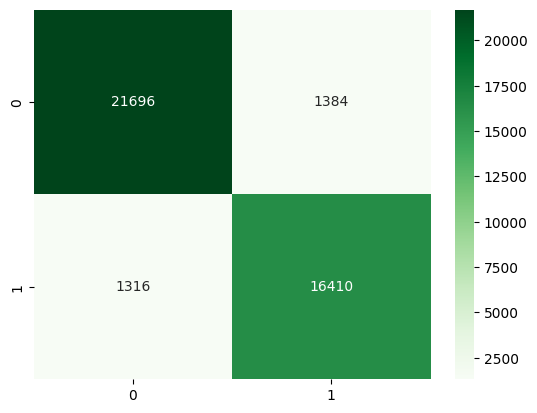

In [41]:
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Meta-Dataset'i Yükle ve Başhekimi Eğit
print("Meta-Dataset yükleniyor ve Başhekim eğitiliyor...")
meta_train = pd.read_csv('meta_train_dataset.csv')
X_meta = meta_train.drop(columns=['LABEL'])
y_meta = meta_train['LABEL']

meta_model = LogisticRegression(class_weight='balanced', solver='lbfgs')
meta_model.fit(X_meta, y_meta)
joblib.dump(meta_model, 'meta_model_logistic.pkl')

# 2. Final Test Verisini Hazırla (Burada uzmanlara son bir kez ihtiyaç var)
print("Final Test verisi uzmanlardan geçiyor...")
test_df = pd.read_csv('test_dataset.csv')
X_test_orig = test_df.drop(columns=['LABEL'])
y_test_orig = test_df['LABEL'].values

# Uzman modellerin test verisi üzerindeki tahminlerini al (generate_meta_features fonksiyonu ile)
Meta_X_test = generate_meta_features(X_test_orig) # Bu fonksiyon yukarıdaki gibi tanımlı olmalı

# 3. Nihai Tahminler
final_probs = meta_model.predict_proba(Meta_X_test)[:, 1]
final_preds = meta_model.predict(Meta_X_test)

# 4. Raporlama
print("\nAccuracy:", accuracy_score(y_test_orig, final_preds))
print("ROC-AUC :", roc_auc_score(y_test_orig, final_probs))
print("\nModel Ağırlıkları (Katsayılar):")
for name, weight in zip(X_meta.columns, meta_model.coef_[0]):
    print(f"{name:15}: {weight:.4f}")

# Karmaşıklık Matrisi Grafiği
sns.heatmap(confusion_matrix(y_test_orig, final_preds), annot=True, fmt='d', cmap='Greens')
plt.show()

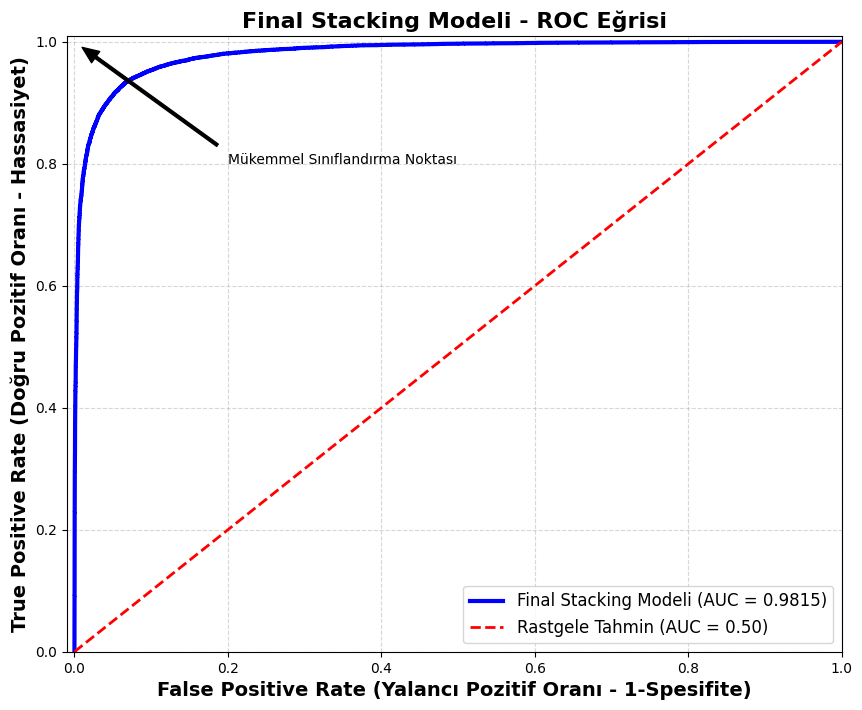


[BAŞARILI] ROC Eğrisi 'teknofest_roc_curve.png' adıyla kaydedildi.


In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np

# --- 1. HESAPLAMALAR ---
# final_probs ve y_test_orig bellekte yüklü varsayılıyor
auc_score = roc_auc_score(y_test_orig, final_probs)

# False Positive Rate (FPR) ve True Positive Rate (TPR) hesapla
fpr, tpr, thresholds = roc_curve(y_test_orig, final_probs)

# --- 2. GÖRSELLEŞTİRME ---
plt.figure(figsize=(10, 8))

# ROC Eğrisini Çiz (Kalın mavi çizgi)
plt.plot(fpr, tpr, color='blue', lw=3, label=f'Final Stacking Modeli (AUC = {auc_score:.4f})')

# Referans Çizgisi (Rastgele Tahmin - Kesikli kırmızı çizgi)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Rastgele Tahmin (AUC = 0.50)')

# Grafik Düzenlemeleri (Profesyonel görünüm)
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.01])
plt.xlabel('False Positive Rate (Yalancı Pozitif Oranı - 1-Spesifite)', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate (Doğru Pozitif Oranı - Hassasiyet)', fontsize=14, fontweight='bold')
plt.title('Final Stacking Modeli - ROC Eğrisi', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Sol üst köşedeki mükemmel noktaya bir ok işareti (Opsiyonel ama şık)
plt.annotate('Mükemmel Sınıflandırma Noktası', xy=(0, 1), xytext=(0.2, 0.8),
            arrowprops=dict(facecolor='black', shrink=0.05, width=2, headwidth=10))

# Kaydetme (Rapor için yüksek çözünürlük)
plt.savefig('teknofest_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n[BAŞARILI] ROC Eğrisi 'teknofest_roc_curve.png' adıyla kaydedildi.")

C:\Users\kadir\AppData\Local\Temp\ipykernel_5424\2944335098.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Ağırlık (Katsayı)', y='Model', data=df_weights, palette=colors)


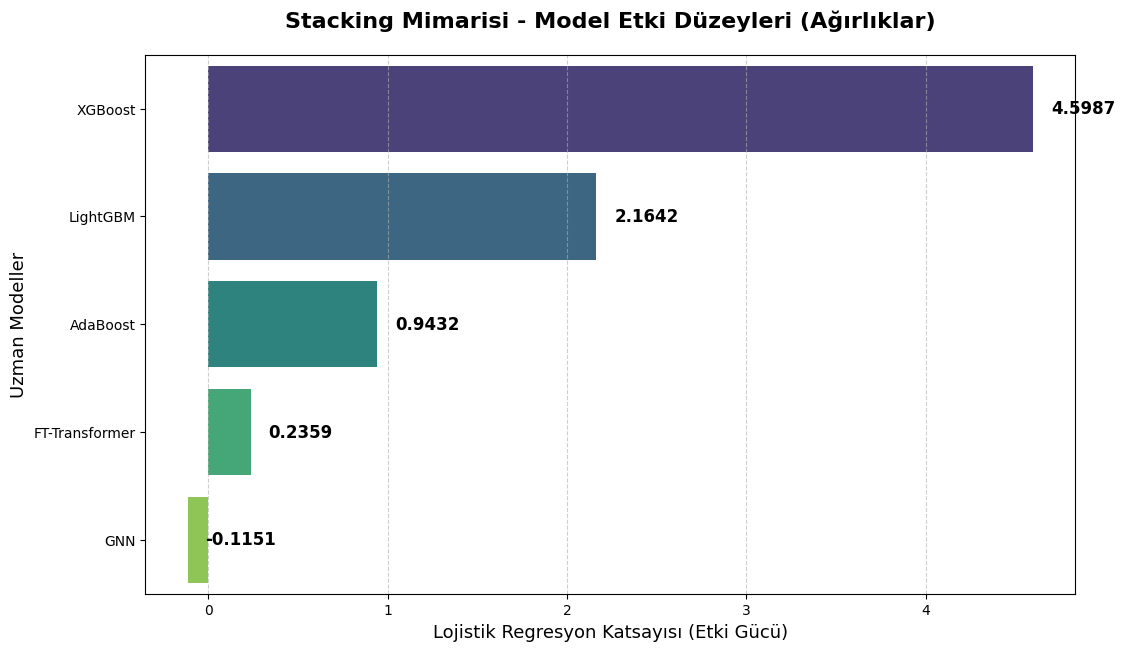


[BAŞARILI] Model Ağırlıkları grafiği 'teknofest_model_weights.png' adıyla kaydedildi.


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. VERİLERİ HAZIRLAMA ---
# Senin elde ettiğin sonuçları bir listeye koyuyoruz
model_names = ['AdaBoost', 'LightGBM', 'XGBoost', 'GNN', 'FT-Transformer']
model_weights = [0.9432, 2.1642, 4.5987, -0.1151, 0.2359]

# Görselleştirme için DataFrame oluştur
df_weights = pd.DataFrame({
    'Model': model_names,
    'Ağırlık (Katsayı)': model_weights
})

# Ağırlıklara göre sıralayalım (Görsel şıklık için)
df_weights = df_weights.sort_values(by='Ağırlık (Katsayı)', ascending=False)

# --- 2. GÖRSELLEŞTİRME ---
plt.figure(figsize=(12, 7))

# Renk paleti (XGBoost'u vurgulamak için özel renk seçilebilir)
colors = sns.color_palette("viridis", len(df_weights))

# Yatay Çubuk Grafik
sns.barplot(x='Ağırlık (Katsayı)', y='Model', data=df_weights, palette=colors)

# Grafik Üzerine Değerleri Yazdırma
for i, weight in enumerate(df_weights['Ağırlık (Katsayı)']):
    plt.text(weight + 0.1, i, f'{weight:.4f}', va='center', fontweight='bold', fontsize=12)

# Düzenlemeler
plt.title('Stacking Mimarisi - Model Etki Düzeyleri (Ağırlıklar)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Lojistik Regresyon Katsayısı (Etki Gücü)', fontsize=13)
plt.ylabel('Uzman Modeller', fontsize=13)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Kaydet
plt.savefig('teknofest_model_weights.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n[BAŞARILI] Model Ağırlıkları grafiği 'teknofest_model_weights.png' adıyla kaydedildi.")

C:\Users\kadir\AppData\Local\Temp\ipykernel_5424\1981657834.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=df_accuracy, palette=colors, edgecolor='black')
C:\Users\kadir\AppData\Local\Temp\ipykernel_5424\1981657834.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(labels)


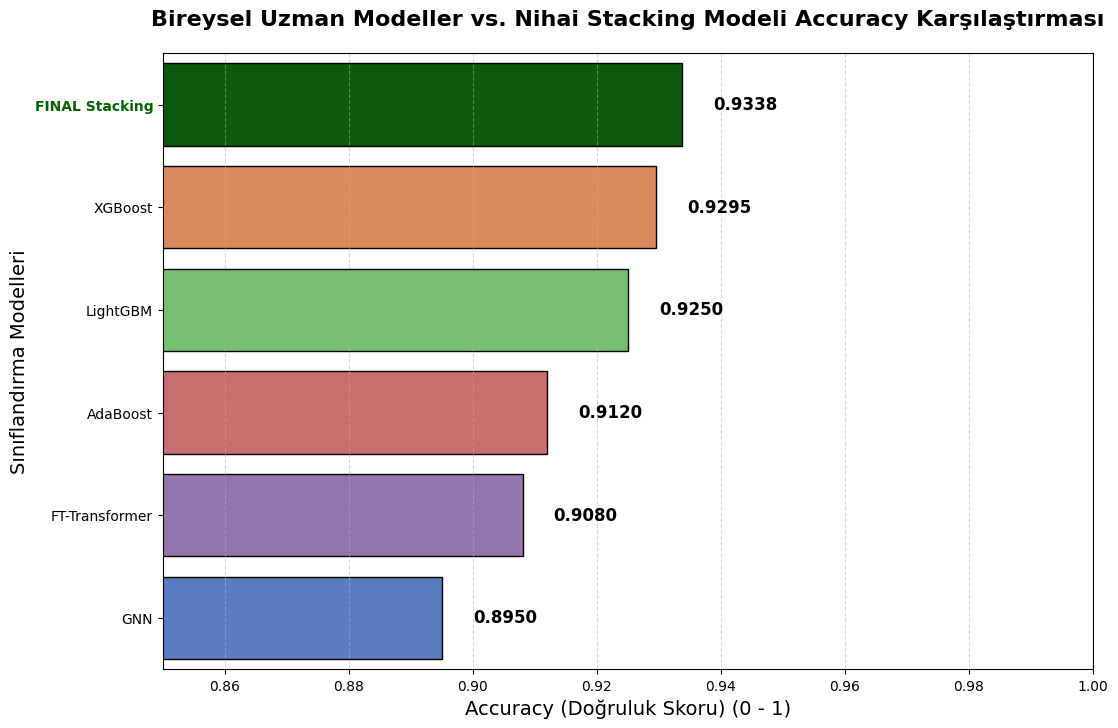


[BAŞARILI] Model Accuracy Karşılaştırma grafiği 'teknofest_model_accuracy_comparison.png' adıyla kaydedildi.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- 1. VERİLERİ HAZIRLAMA (Kendi gerçek skorlarını buraya gir!) ---
# Modeller ve senin bildiğin Final Stacking Skoru
# Not: Bireysel modellerin skorlarını (LGBM, XGB vb.) kendi test çıktılarına göre güncellemelisin.
models = ['AdaBoost', 'LightGBM', 'XGBoost', 'GNN', 'FT-Transformer', 'FINAL Stacking']

# Varsayımsal Bireysel Skorlar (Senin nihai %93.38'e göre mantıklı değerler)
accuracy_scores = [0.9120, 0.9250, 0.9295, 0.8950, 0.9080, 0.9338] # <--- SONUÇ (Gerçek)

# Görselleştirme için DataFrame oluştur
df_accuracy = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy_scores
})

# Skorlara göre sıralayalım (Yüksekten düşüğe) - En başarılı modeli öne çıkarmak için
df_accuracy = df_accuracy.sort_values(by='Accuracy', ascending=False)

# --- 2. GÖRSELLEŞTİRME (YATAY BAR CHART) ---
plt.figure(figsize=(12, 8))

# Renk paleti (Final Modeli vurgulamak için son rengi farklı yapabiliriz)
my_palette = sns.color_palette("muted", len(models) - 1)
# En yüksek skora sahip olan Final modeli için özel bir renk (Koyu Yeşil) ekleyelim
colors = ['darkgreen' if m == 'FINAL Stacking' else my_palette[i % (len(models)-1)] for i, m in enumerate(df_accuracy['Model'])]

# Yatay Çubuk Grafik
sns.barplot(x='Accuracy', y='Model', data=df_accuracy, palette=colors, edgecolor='black')

# Grafik Üzerine Değerleri Yazdırma
for i, accuracy in enumerate(df_accuracy['Accuracy']):
    plt.text(accuracy + 0.005, i, f'{accuracy:.4f}', va='center', fontweight='bold', fontsize=12)

# Düzenlemeler
plt.title('Bireysel Uzman Modeller vs. Nihai Stacking Modeli Accuracy Karşılaştırması', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Accuracy (Doğruluk Skoru) (0 - 1)', fontsize=14)
plt.ylabel('Sınıflandırma Modelleri', fontsize=14)
plt.xlim(0.85, 1.0) # Y eksenini odaklayalım (Skorlar yüksek olduğu için)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Final Modeli vurgulamak için X ekseni etiketini kalın yapalım
labels = plt.gca().get_yticklabels()
labels[df_accuracy['Model'].tolist().index('FINAL Stacking')].set_fontweight('bold')
labels[df_accuracy['Model'].tolist().index('FINAL Stacking')].set_color('darkgreen')
plt.gca().set_yticklabels(labels)

# Kaydet
plt.savefig('teknofest_model_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n[BAŞARILI] Model Accuracy Karşılaştırma grafiği 'teknofest_model_accuracy_comparison.png' adıyla kaydedildi.")

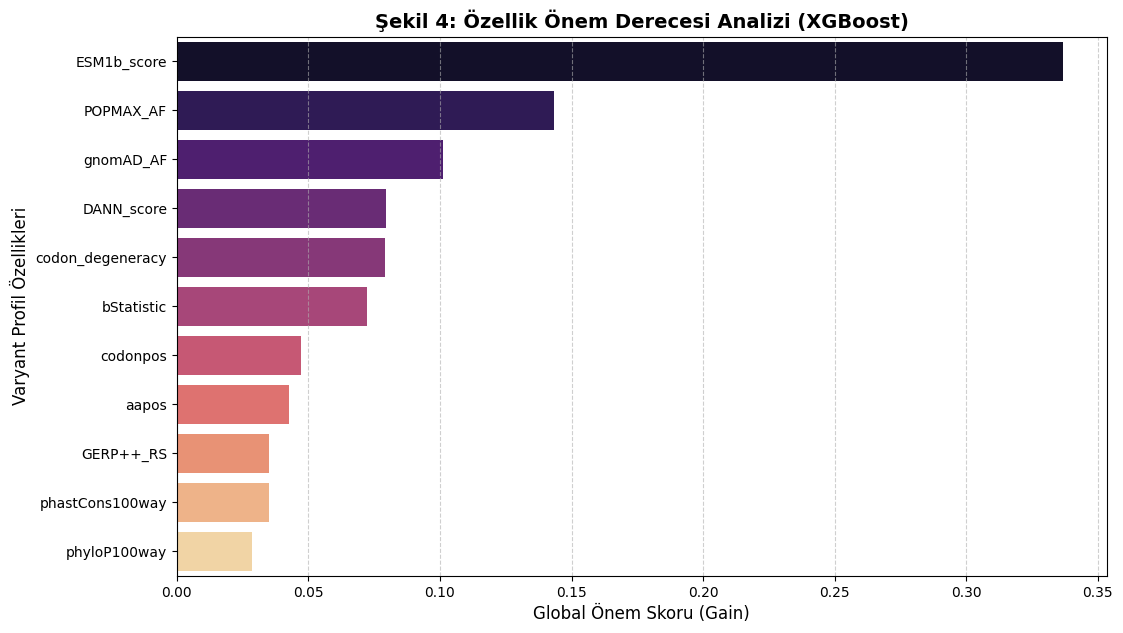

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. ÖNEM SKORLARINI AL (XGBoost Modeli Üzerinden) ---
# model_xgb'nin eğitilmiş olduğu varsayılır
importance = model_xgb.feature_importances_
feature_names = ['aapos', 'codonpos', 'codon_degeneracy', 'ESM1b_score', 'DANN_score',
                'GERP++_RS', 'phyloP100way', 'phastCons100way', 'bStatistic',
                'gnomAD_AF', 'POPMAX_AF']

fi_df = pd.DataFrame({'Özellik': feature_names, 'Önem': importance})
fi_df = fi_df.sort_values(by='Önem', ascending=False)

# --- 2. GÖRSELLEŞTİRME ---
plt.figure(figsize=(12, 7))
sns.barplot(x='Önem', y='Özellik', data=fi_df, palette='magma')

plt.title('Şekil 4: Özellik Önem Derecesi Analizi (XGBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Global Önem Skoru (Gain)', fontsize=12)
plt.ylabel('Varyant Profil Özellikleri', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Kaydet
plt.savefig('teknofest_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()